In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [5]:
df = pd.read_csv("/content/telecom_churn_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (99999, 226)


,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,...,0,1.0,1.0,1.0,NaN,968,30.4,0.0,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.0,0.0,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.0,0.0,4.17,0.00
3,7001204172,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,221.338,...,0,NaN,NaN,NaN,NaN,2491,0.0,0.0,0.00,0.00
4,7000142493,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,261.636,...,0,0.0,NaN,NaN,NaN,1526,0.0,0.0,0.00,0.00


In [6]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (99999, 226)

Column names:
['mobile_number', 'circle_id', 'loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou', 'last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8', 'last_date_of_month_9', 'arpu_6', 'arpu_7', 'arpu_8', 'arpu_9', 'onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'onnet_mou_9', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8', 'offnet_mou_9', 'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8', 'roam_ic_mou_9', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8', 'roam_og_mou_9', 'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8', 'loc_og_t2t_mou_9', 'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8', 'loc_og_t2m_mou_9', 'loc_og_t2f_mou_6', 'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8', 'loc_og_t2f_mou_9', 'loc_og_t2c_mou_6', 'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8', 'loc_og_t2c_mou_9', 'loc_og_mou_6', 'loc_og_mou_7', 'loc_og_mou_8', 'loc_og_mou_9', 'std_og_t2t_mou_6', 'std_og_t2t_mou_7', 'std_og_t2t_mou_8', 'std_og_t2t_mou_9', 'std_og_t2m_

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Columns: 226 entries, mobile_number to sep_vbc_3g
dtypes: float64(179), int64(35), object(12)
memory usage: 172.4+ MB
None


In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate mobile numbers:", df['mobile_number'].duplicated().sum())

Duplicate rows: 0
Duplicate mobile numbers: 0


In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns containing missing values:")
print(missing)

Columns containing missing values:
fb_user_6               74846
night_pck_user_6        74846
count_rech_3g_6         74846
av_rech_amt_data_6      74846
count_rech_2g_6         74846
                        ...  
last_date_of_month_8     1100
loc_ic_t2o_mou           1018
std_og_t2o_mou           1018
loc_og_t2o_mou           1018
last_date_of_month_7      601
Length: 166, dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

print("Missing percentage:")
print(missing_percentage)

Missing percentage:
fb_user_6               74.846748
night_pck_user_6        74.846748
count_rech_3g_6         74.846748
av_rech_amt_data_6      74.846748
count_rech_2g_6         74.846748
                          ...    
last_date_of_month_8     1.100011
loc_ic_t2o_mou           1.018010
std_og_t2o_mou           1.018010
loc_og_t2o_mou           1.018010
last_date_of_month_7     0.601006
Length: 166, dtype: float64


In [11]:
for month in ['_6', '_7', '_8', '_9']:
    cols = [c for c in df.columns if c.endswith(month)]
    print(f"{month}: {len(cols)} columns")

_6: 54 columns
_7: 54 columns
_8: 54 columns
_9: 54 columns


In [12]:
for month in ['_6', '_7', '_8', '_9']:
    cols = [c for c in df.columns if c.endswith(month)]
    print(f"\n===== MONTH {month} =====")
    print(cols)


===== MONTH _6 =====
['last_date_of_month_6', 'arpu_6', 'onnet_mou_6', 'offnet_mou_6', 'roam_ic_mou_6', 'roam_og_mou_6', 'loc_og_t2t_mou_6', 'loc_og_t2m_mou_6', 'loc_og_t2f_mou_6', 'loc_og_t2c_mou_6', 'loc_og_mou_6', 'std_og_t2t_mou_6', 'std_og_t2m_mou_6', 'std_og_t2f_mou_6', 'std_og_t2c_mou_6', 'std_og_mou_6', 'isd_og_mou_6', 'spl_og_mou_6', 'og_others_6', 'total_og_mou_6', 'loc_ic_t2t_mou_6', 'loc_ic_t2m_mou_6', 'loc_ic_t2f_mou_6', 'loc_ic_mou_6', 'std_ic_t2t_mou_6', 'std_ic_t2m_mou_6', 'std_ic_t2f_mou_6', 'std_ic_t2o_mou_6', 'std_ic_mou_6', 'total_ic_mou_6', 'spl_ic_mou_6', 'isd_ic_mou_6', 'ic_others_6', 'total_rech_num_6', 'total_rech_amt_6', 'max_rech_amt_6', 'date_of_last_rech_6', 'last_day_rch_amt_6', 'date_of_last_rech_data_6', 'total_rech_data_6', 'max_rech_data_6', 'count_rech_2g_6', 'count_rech_3g_6', 'av_rech_amt_data_6', 'vol_2g_mb_6', 'vol_3g_mb_6', 'arpu_3g_6', 'arpu_2g_6', 'night_pck_user_6', 'monthly_2g_6', 'sachet_2g_6', 'monthly_3g_6', 'sachet_3g_6', 'fb_user_6']

=

In [13]:
# Display all 54 features for August

august_cols = [c for c in df.columns if c.endswith('_8')]

print("Number of August features:", len(august_cols))

for i, col in enumerate(august_cols, 1):
    print(f"{i:2}. {col}")

Number of August features: 54
 1. last_date_of_month_8
 2. arpu_8
 3. onnet_mou_8
 4. offnet_mou_8
 5. roam_ic_mou_8
 6. roam_og_mou_8
 7. loc_og_t2t_mou_8
 8. loc_og_t2m_mou_8
 9. loc_og_t2f_mou_8
10. loc_og_t2c_mou_8
11. loc_og_mou_8
12. std_og_t2t_mou_8
13. std_og_t2m_mou_8
14. std_og_t2f_mou_8
15. std_og_t2c_mou_8
16. std_og_mou_8
17. isd_og_mou_8
18. spl_og_mou_8
19. og_others_8
20. total_og_mou_8
21. loc_ic_t2t_mou_8
22. loc_ic_t2m_mou_8
23. loc_ic_t2f_mou_8
24. loc_ic_mou_8
25. std_ic_t2t_mou_8
26. std_ic_t2m_mou_8
27. std_ic_t2f_mou_8
28. std_ic_t2o_mou_8
29. std_ic_mou_8
30. total_ic_mou_8
31. spl_ic_mou_8
32. isd_ic_mou_8
33. ic_others_8
34. total_rech_num_8
35. total_rech_amt_8
36. max_rech_amt_8
37. date_of_last_rech_8
38. last_day_rch_amt_8
39. date_of_last_rech_data_8
40. total_rech_data_8
41. max_rech_data_8
42. count_rech_2g_8
43. count_rech_3g_8
44. av_rech_amt_data_8
45. vol_2g_mb_8
46. vol_3g_mb_8
47. arpu_3g_8
48. arpu_2g_8
49. night_pck_user_8
50. monthly_2g_8
51. 

In [14]:
# Display all 54 features for September

september_cols = [c for c in df.columns if c.endswith('_9')]

print("Number of September features:", len(september_cols))

for i, col in enumerate(september_cols, 1):
    print(f"{i:2}. {col}")

Number of September features: 54
 1. last_date_of_month_9
 2. arpu_9
 3. onnet_mou_9
 4. offnet_mou_9
 5. roam_ic_mou_9
 6. roam_og_mou_9
 7. loc_og_t2t_mou_9
 8. loc_og_t2m_mou_9
 9. loc_og_t2f_mou_9
10. loc_og_t2c_mou_9
11. loc_og_mou_9
12. std_og_t2t_mou_9
13. std_og_t2m_mou_9
14. std_og_t2f_mou_9
15. std_og_t2c_mou_9
16. std_og_mou_9
17. isd_og_mou_9
18. spl_og_mou_9
19. og_others_9
20. total_og_mou_9
21. loc_ic_t2t_mou_9
22. loc_ic_t2m_mou_9
23. loc_ic_t2f_mou_9
24. loc_ic_mou_9
25. std_ic_t2t_mou_9
26. std_ic_t2m_mou_9
27. std_ic_t2f_mou_9
28. std_ic_t2o_mou_9
29. std_ic_mou_9
30. total_ic_mou_9
31. spl_ic_mou_9
32. isd_ic_mou_9
33. ic_others_9
34. total_rech_num_9
35. total_rech_amt_9
36. max_rech_amt_9
37. date_of_last_rech_9
38. last_day_rch_amt_9
39. date_of_last_rech_data_9
40. total_rech_data_9
41. max_rech_data_9
42. count_rech_2g_9
43. count_rech_3g_9
44. av_rech_amt_data_9
45. vol_2g_mb_9
46. vol_3g_mb_9
47. arpu_3g_9
48. arpu_2g_9
49. night_pck_user_9
50. monthly_2g_9
5

In [15]:
# Identify monthly and non-monthly columns

monthly_suffixes = ['_6', '_7', '_8', '_9']

monthly_cols = [
    col for col in df.columns
    if any(col.endswith(suffix) for suffix in monthly_suffixes)
]

non_monthly_cols = [
    col for col in df.columns
    if col not in monthly_cols
]

print("Total columns:", len(df.columns))
print("Monthly columns:", len(monthly_cols))
print("Non-monthly columns:", len(non_monthly_cols))

print("\nNon-monthly columns:")
for col in non_monthly_cols:
    print(col)

Total columns: 226
Monthly columns: 216
Non-monthly columns: 10

Non-monthly columns:
mobile_number
circle_id
loc_og_t2o_mou
std_og_t2o_mou
loc_ic_t2o_mou
aon
aug_vbc_3g
jul_vbc_3g
jun_vbc_3g
sep_vbc_3g


In [16]:
print(df[non_monthly_cols].head())

print("\nUnique values in non-monthly columns:")
for col in non_monthly_cols:
    print(f"\n{col}")
    print("Unique:", df[col].nunique())
    print(df[col].dropna().unique()[:20])

   mobile_number  circle_id  loc_og_t2o_mou  std_og_t2o_mou  loc_ic_t2o_mou  \
0     7000842753        109             0.0             0.0             0.0   
1     7001865778        109             0.0             0.0             0.0   
2     7001625959        109             0.0             0.0             0.0   
3     7001204172        109             0.0             0.0             0.0   
4     7000142493        109             0.0             0.0             0.0   

    aon  aug_vbc_3g  jul_vbc_3g  jun_vbc_3g  sep_vbc_3g  
0   968        30.4         0.0      101.20        3.58  
1  1006         0.0         0.0        0.00        0.00  
2  1103         0.0         0.0        4.17        0.00  
3  2491         0.0         0.0        0.00        0.00  
4  1526         0.0         0.0        0.00        0.00  

Unique values in non-monthly columns:

mobile_number
Unique: 99999
[7000842753 7001865778 7001625959 7001204172 7000142493 7000286308
 7001051193 7000701601 7001524846 70018644

In [17]:
# Search for columns that may represent churn / target

possible_target_cols = [
    col for col in df.columns
    if any(word in col.lower() for word in
           ['churn', 'churned', 'target', 'label', 'retention'])
]

print("Possible target columns:")
print(possible_target_cols)

Possible target columns:
[]


In [18]:
# ==========================================
# STEP 1: Inspect September customer activity
# ==========================================

sep_cols = [c for c in df.columns if c.endswith('_9')]

print("Number of September features:", len(sep_cols))
print("\nSeptember features:")
for col in sep_cols:
    print(col)

Number of September features: 54

September features:
last_date_of_month_9
arpu_9
onnet_mou_9
offnet_mou_9
roam_ic_mou_9
roam_og_mou_9
loc_og_t2t_mou_9
loc_og_t2m_mou_9
loc_og_t2f_mou_9
loc_og_t2c_mou_9
loc_og_mou_9
std_og_t2t_mou_9
std_og_t2m_mou_9
std_og_t2f_mou_9
std_og_t2c_mou_9
std_og_mou_9
isd_og_mou_9
spl_og_mou_9
og_others_9
total_og_mou_9
loc_ic_t2t_mou_9
loc_ic_t2m_mou_9
loc_ic_t2f_mou_9
loc_ic_mou_9
std_ic_t2t_mou_9
std_ic_t2m_mou_9
std_ic_t2f_mou_9
std_ic_t2o_mou_9
std_ic_mou_9
total_ic_mou_9
spl_ic_mou_9
isd_ic_mou_9
ic_others_9
total_rech_num_9
total_rech_amt_9
max_rech_amt_9
date_of_last_rech_9
last_day_rch_amt_9
date_of_last_rech_data_9
total_rech_data_9
max_rech_data_9
count_rech_2g_9
count_rech_3g_9
av_rech_amt_data_9
vol_2g_mb_9
vol_3g_mb_9
arpu_3g_9
arpu_2g_9
night_pck_user_9
monthly_2g_9
sachet_2g_9
monthly_3g_9
sachet_3g_9
fb_user_9


In [19]:
# Columns related to customer activity in September

activity_keywords = [
    'mou',
    'rech',
    'vol',
    'arpu',
    'monthly',
    'sachet',
    'vbc'
]

activity_cols = [
    col for col in sep_cols
    if any(keyword in col.lower() for keyword in activity_keywords)
]

print("Potential activity columns:")
for col in activity_cols:
    print(col)

Potential activity columns:
arpu_9
onnet_mou_9
offnet_mou_9
roam_ic_mou_9
roam_og_mou_9
loc_og_t2t_mou_9
loc_og_t2m_mou_9
loc_og_t2f_mou_9
loc_og_t2c_mou_9
loc_og_mou_9
std_og_t2t_mou_9
std_og_t2m_mou_9
std_og_t2f_mou_9
std_og_t2c_mou_9
std_og_mou_9
isd_og_mou_9
spl_og_mou_9
total_og_mou_9
loc_ic_t2t_mou_9
loc_ic_t2m_mou_9
loc_ic_t2f_mou_9
loc_ic_mou_9
std_ic_t2t_mou_9
std_ic_t2m_mou_9
std_ic_t2f_mou_9
std_ic_t2o_mou_9
std_ic_mou_9
total_ic_mou_9
spl_ic_mou_9
isd_ic_mou_9
total_rech_num_9
total_rech_amt_9
max_rech_amt_9
date_of_last_rech_9
date_of_last_rech_data_9
total_rech_data_9
max_rech_data_9
count_rech_2g_9
count_rech_3g_9
av_rech_amt_data_9
vol_2g_mb_9
vol_3g_mb_9
arpu_3g_9
arpu_2g_9
monthly_2g_9
sachet_2g_9
monthly_3g_9
sachet_3g_9


In [20]:
# Check whether customers have any activity in September

print("September activity summary:\n")

check_cols = [
    'total_og_mou_9',
    'total_ic_mou_9',
    'vol_2g_mb_9',
    'vol_3g_mb_9'
]

for col in check_cols:
    if col in df.columns:
        print(
            col,
            "→ zero values:",
            (df[col].fillna(0) == 0).sum(),
            "/",
            len(df)
        )

September activity summary:

total_og_mou_9 → zero values: 14143 / 99999
total_ic_mou_9 → zero values: 11485 / 99999
vol_2g_mb_9 → zero values: 78279 / 99999
vol_3g_mb_9 → zero values: 84638 / 99999


In [21]:
# ==========================================
# STEP 4: Identify completely inactive users
# ==========================================

# Treat missing activity values as zero
og_sep = df['total_og_mou_9'].fillna(0)
ic_sep = df['total_ic_mou_9'].fillna(0)
data_2g_sep = df['vol_2g_mb_9'].fillna(0)
data_3g_sep = df['vol_3g_mb_9'].fillna(0)

# Voice inactivity
voice_inactive = (og_sep == 0) & (ic_sep == 0)

# Complete inactivity: no outgoing/incoming voice AND no 2G/3G usage
complete_inactive = (
    (og_sep == 0) &
    (ic_sep == 0) &
    (data_2g_sep == 0) &
    (data_3g_sep == 0)
)

print("Voice-inactive customers:", voice_inactive.sum())
print("Completely inactive customers:", complete_inactive.sum())

print("\nPercentages:")
print(
    "Voice inactive:",
    round(voice_inactive.mean() * 100, 2),
    "%"
)

print(
    "Completely inactive:",
    round(complete_inactive.mean() * 100, 2),
    "%"
)

Voice-inactive customers: 10889
Completely inactive customers: 10191

Percentages:
Voice inactive: 10.89 %
Completely inactive: 10.19 %


In [22]:
# ==========================================
# STEP 5: Check whether September inactivity
# was preceded by activity
# ==========================================

# Total voice activity for each month
for month in ['6', '7', '8', '9']:
    df[f'voice_activity_{month}'] = (
        df[f'total_og_mou_{month}'].fillna(0) +
        df[f'total_ic_mou_{month}'].fillna(0)
    )

print("Voice activity statistics:")
print(
    df[
        [
            'voice_activity_6',
            'voice_activity_7',
            'voice_activity_8',
            'voice_activity_9'
        ]
    ].describe()
)

Voice activity statistics:
       voice_activity_6  voice_activity_7  voice_activity_8  voice_activity_9
count      99999.000000      99999.000000      99999.000000      99999.000000
mean         505.263461        513.084230        502.870295        478.493458
std          603.204051        618.563036        612.932772        606.003442
min            0.000000          0.000000          0.000000          0.000000
25%          122.555000        123.980000        115.340000         90.930000
50%          320.990000        320.420000        314.520000        291.260000
75%          668.100000        678.650000        667.595000        640.295000
max        12311.260000      11476.290000      14079.840000      12852.510000


In [23]:
# ==========================================
# STEP 6: Look at customers who became
# inactive in September
# ==========================================

newly_inactive = (
    (df['voice_activity_9'] == 0) &
    (df['voice_activity_8'] > 0)
)

already_inactive = (
    (df['voice_activity_9'] == 0) &
    (df['voice_activity_8'] == 0)
)

print("Newly inactive in September:", newly_inactive.sum())
print("Already inactive in August:", already_inactive.sum())

print(
    "\nNewly inactive percentage:",
    round(newly_inactive.mean() * 100, 2),
    "%"
)

print(
    "Already inactive percentage:",
    round(already_inactive.mean() * 100, 2),
    "%"
)

Newly inactive in September: 3995
Already inactive in August: 6894

Newly inactive percentage: 4.0 %
Already inactive percentage: 6.89 %


In [24]:
# Create activity indicators for each month

for month in ['6', '7', '8', '9']:
    df[f'voice_active_{month}'] = (
        (df[f'total_og_mou_{month}'] > 0) |
        (df[f'total_ic_mou_{month}'] > 0)
    ).astype(int)

    df[f'data_active_{month}'] = (
        (df[f'vol_2g_mb_{month}'] > 0) |
        (df[f'vol_3g_mb_{month}'] > 0)
    ).astype(int)

print("Activity indicators created.")

print(
    df[
        [
            'mobile_number',
            'voice_active_6',
            'voice_active_7',
            'voice_active_8',
            'voice_active_9',
            'data_active_6',
            'data_active_7',
            'data_active_8',
            'data_active_9'
        ]
    ].head()
)

Activity indicators created.
   mobile_number  voice_active_6  voice_active_7  voice_active_8  \
0     7000842753               0               0               1   
1     7001865778               1               1               1   
2     7001625959               1               1               1   
3     7001204172               1               1               1   
4     7000142493               1               1               1   

   voice_active_9  data_active_6  data_active_7  data_active_8  data_active_9  
0               0              1              1              1              0  
1               1              0              1              1              0  
2               1              0              0              0              1  
3               1              0              0              0              0  
4               1              0              0              0              0  


In [25]:
# ============================================================
# STEP 8: CREATE TEMPORAL PREDICTION TARGET
# ============================================================

# A customer is considered voice-inactive in September
# if they have neither outgoing nor incoming voice activity.

df['september_inactive'] = (
    (df['voice_active_9'] == 0)
).astype(int)

# A customer is "newly inactive" if:
# 1. They were active in August
# 2. They became inactive in September

df['newly_inactive'] = (
    (df['voice_active_8'] == 1) &
    (df['voice_active_9'] == 0)
).astype(int)

print("Target distribution:")
print(df['newly_inactive'].value_counts())

print("\nTarget percentages:")
print(
    df['newly_inactive']
    .value_counts(normalize=True)
    .mul(100)
)

print("\nNewly inactive customers:")
print(df['newly_inactive'].sum())

print("\nSample:")
print(
    df[
        [
            'mobile_number',
            'voice_active_6',
            'voice_active_7',
            'voice_active_8',
            'voice_active_9',
            'newly_inactive'
        ]
    ].head(10)
)

Target distribution:
newly_inactive
0    96004
1     3995
Name: count, dtype: int64

Target percentages:
newly_inactive
0    96.00496
1     3.99504
Name: proportion, dtype: float64

Newly inactive customers:
3995

Sample:
   mobile_number  voice_active_6  voice_active_7  voice_active_8  \
0     7000842753               0               0               1   
1     7001865778               1               1               1   
2     7001625959               1               1               1   
3     7001204172               1               1               1   
4     7000142493               1               1               1   
5     7000286308               1               1               1   
6     7001051193               1               1               1   
7     7000701601               1               1               1   
8     7001524846               1               1               1   
9     7001864400               1               1               1   

   voice_active_9  newly_inac

In [26]:
# ============================================================
# STEP 9A: IDENTIFY TEMPORAL FEATURE BLOCKS
# ============================================================

months = ['6', '7', '8']

monthly_features = {}

for month in months:
    cols = [c for c in df.columns if c.endswith(f'_{month}')]
    monthly_features[month] = cols

    print(f"Month {month}: {len(cols)} features")

print("\nJune features:")
print(monthly_features['6'])

print("\nJuly features:")
print(monthly_features['7'])

print("\nAugust features:")
print(monthly_features['8'])

Month 6: 57 features
Month 7: 57 features
Month 8: 57 features

June features:
['last_date_of_month_6', 'arpu_6', 'onnet_mou_6', 'offnet_mou_6', 'roam_ic_mou_6', 'roam_og_mou_6', 'loc_og_t2t_mou_6', 'loc_og_t2m_mou_6', 'loc_og_t2f_mou_6', 'loc_og_t2c_mou_6', 'loc_og_mou_6', 'std_og_t2t_mou_6', 'std_og_t2m_mou_6', 'std_og_t2f_mou_6', 'std_og_t2c_mou_6', 'std_og_mou_6', 'isd_og_mou_6', 'spl_og_mou_6', 'og_others_6', 'total_og_mou_6', 'loc_ic_t2t_mou_6', 'loc_ic_t2m_mou_6', 'loc_ic_t2f_mou_6', 'loc_ic_mou_6', 'std_ic_t2t_mou_6', 'std_ic_t2m_mou_6', 'std_ic_t2f_mou_6', 'std_ic_t2o_mou_6', 'std_ic_mou_6', 'total_ic_mou_6', 'spl_ic_mou_6', 'isd_ic_mou_6', 'ic_others_6', 'total_rech_num_6', 'total_rech_amt_6', 'max_rech_amt_6', 'date_of_last_rech_6', 'last_day_rch_amt_6', 'date_of_last_rech_data_6', 'total_rech_data_6', 'max_rech_data_6', 'count_rech_2g_6', 'count_rech_3g_6', 'av_rech_amt_data_6', 'vol_2g_mb_6', 'vol_3g_mb_6', 'arpu_3g_6', 'arpu_2g_6', 'night_pck_user_6', 'monthly_2g_6', 'sac

In [27]:
# Explicitly include the VBC monthly features

june_features = [
    c for c in df.columns
    if c.endswith('_6')
]

july_features = [
    c for c in df.columns
    if c.endswith('_7')
]

august_features = [
    c for c in df.columns
    if c.endswith('_8')
]

# Add the VBC features that don't follow the _month naming convention
june_features.append('jun_vbc_3g')
july_features.append('jul_vbc_3g')
august_features.append('aug_vbc_3g')

print("June features:", len(june_features))
print("July features:", len(july_features))
print("August features:", len(august_features))

print("\nJune:")
print(june_features)

print("\nJuly:")
print(july_features)

print("\nAugust:")
print(august_features)

June features: 58
July features: 58
August features: 58

June:
['last_date_of_month_6', 'arpu_6', 'onnet_mou_6', 'offnet_mou_6', 'roam_ic_mou_6', 'roam_og_mou_6', 'loc_og_t2t_mou_6', 'loc_og_t2m_mou_6', 'loc_og_t2f_mou_6', 'loc_og_t2c_mou_6', 'loc_og_mou_6', 'std_og_t2t_mou_6', 'std_og_t2m_mou_6', 'std_og_t2f_mou_6', 'std_og_t2c_mou_6', 'std_og_mou_6', 'isd_og_mou_6', 'spl_og_mou_6', 'og_others_6', 'total_og_mou_6', 'loc_ic_t2t_mou_6', 'loc_ic_t2m_mou_6', 'loc_ic_t2f_mou_6', 'loc_ic_mou_6', 'std_ic_t2t_mou_6', 'std_ic_t2m_mou_6', 'std_ic_t2f_mou_6', 'std_ic_t2o_mou_6', 'std_ic_mou_6', 'total_ic_mou_6', 'spl_ic_mou_6', 'isd_ic_mou_6', 'ic_others_6', 'total_rech_num_6', 'total_rech_amt_6', 'max_rech_amt_6', 'date_of_last_rech_6', 'last_day_rch_amt_6', 'date_of_last_rech_data_6', 'total_rech_data_6', 'max_rech_data_6', 'count_rech_2g_6', 'count_rech_3g_6', 'av_rech_amt_data_6', 'vol_2g_mb_6', 'vol_3g_mb_6', 'arpu_3g_6', 'arpu_2g_6', 'night_pck_user_6', 'monthly_2g_6', 'sachet_2g_6', 'mont

In [28]:
# ============================================================
# STEP 10.1 — Create historical feature lists
# ============================================================

# We are predicting September, so only use June, July and August.

june_features = [
    c for c in df.columns
    if c.endswith('_6')
]

july_features = [
    c for c in df.columns
    if c.endswith('_7')
]

august_features = [
    c for c in df.columns
    if c.endswith('_8')
]

# Add the month-specific VBC features
june_features.append('jun_vbc_3g')
july_features.append('jul_vbc_3g')
august_features.append('aug_vbc_3g')

# Remove duplicates just in case
june_features = list(dict.fromkeys(june_features))
july_features = list(dict.fromkeys(july_features))
august_features = list(dict.fromkeys(august_features))

print("June features:", len(june_features))
print("July features:", len(july_features))
print("August features:", len(august_features))

June features: 58
July features: 58
August features: 58


In [29]:
# ============================================================
# STEP 10.3 — Create the modelling dataframe
# ============================================================

feature_cols = (
    june_features +
    july_features +
    august_features +
    ['aon']
)

# Remove duplicates
feature_cols = list(dict.fromkeys(feature_cols))

# Create X + target
model_df = df[feature_cols + ['newly_inactive']].copy()

print("Model dataframe shape:", model_df.shape)

print("\nNumber of input features:", len(feature_cols))

print("\nTarget distribution:")
print(model_df['newly_inactive'].value_counts())

Model dataframe shape: (99999, 176)

Number of input features: 175

Target distribution:
newly_inactive
0    96004
1     3995
Name: count, dtype: int64


In [30]:
# ============================================================
# STEP 10.4 — Leakage check
# ============================================================

september_leakage = [
    col for col in model_df.columns
    if '_9' in col or col.startswith('sep_')
]

print("Potential September leakage columns:")
print(september_leakage)

Potential September leakage columns:
[]


In [31]:
# ============================================================
# STEP 10.5 — Check unwanted columns
# ============================================================

unwanted_columns = [
    'mobile_number',
    'circle_id',
    'loc_og_t2o_mou',
    'std_og_t2o_mou',
    'loc_ic_t2o_mou',
    'jun_vbc_3g',
    'jul_vbc_3g',
    'aug_vbc_3g',
    'sep_vbc_3g'
]

present_unwanted = [
    col for col in unwanted_columns
    if col in model_df.columns
]

print("Unwanted columns still present:")
print(present_unwanted)

Unwanted columns still present:
['jun_vbc_3g', 'jul_vbc_3g', 'aug_vbc_3g']


In [32]:
# ============================================================
# STEP 10.6 — Missing-value analysis
# ============================================================

missing = model_df.drop(
    columns=['newly_inactive']
).isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Number of features with missing values:", len(missing))

print("\nTop 30 features by missing percentage:")

missing_percentage = (
    model_df.drop(columns=['newly_inactive'])
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(missing_percentage.head(30))

Number of features with missing values: 122

Top 30 features by missing percentage:
date_of_last_rech_data_6    74.846748
arpu_3g_6                   74.846748
count_rech_2g_6             74.846748
count_rech_3g_6             74.846748
total_rech_data_6           74.846748
max_rech_data_6             74.846748
av_rech_amt_data_6          74.846748
night_pck_user_6            74.846748
fb_user_6                   74.846748
arpu_2g_6                   74.846748
date_of_last_rech_data_7    74.428744
count_rech_2g_7             74.428744
arpu_2g_7                   74.428744
count_rech_3g_7             74.428744
av_rech_amt_data_7          74.428744
arpu_3g_7                   74.428744
max_rech_data_7             74.428744
total_rech_data_7           74.428744
fb_user_7                   74.428744
night_pck_user_7            74.428744
night_pck_user_8            73.660737
date_of_last_rech_data_8    73.660737
arpu_3g_8                   73.660737
count_rech_3g_8             73.660737
av_r

In [33]:
# ============================================================
# STEP 10.7 — Find completely empty features
# ============================================================

completely_missing = [
    col for col in feature_cols
    if model_df[col].isnull().all()
]

print("Completely missing features:")
print(completely_missing)

print("Count:", len(completely_missing))

Completely missing features:
[]
Count: 0


In [34]:
# ============================================================
# STEP 10.8 — Save clean pre-imputation dataset
# ============================================================

model_df.to_csv(
    'telecom_temporal_model_data_raw.csv',
    index=False
)

print("Saved successfully.")
print("Shape:", model_df.shape)

Saved successfully.
Shape: (99999, 176)


In [35]:
# ============================================================
# STEP 10.9 — Remove duplicated VBC columns
# ============================================================

duplicate_vbc_cols = [
    'jun_vbc_3g',
    'jul_vbc_3g',
    'aug_vbc_3g'
]

model_df = model_df.drop(columns=duplicate_vbc_cols)

print("New model dataframe shape:", model_df.shape)
print("New number of input features:", model_df.shape[1] - 1)

New model dataframe shape: (99999, 173)
New number of input features: 172


In [36]:
# ============================================================
# STEP 11 — Inspect feature data types
# ============================================================

feature_dtypes = model_df.drop(
    columns=['newly_inactive']
).dtypes

print(feature_dtypes.value_counts())

print("\nNon-numeric features:")

non_numeric = feature_dtypes[
    ~feature_dtypes.isin(['int64', 'float64', 'int32', 'float32'])
]

print(non_numeric)

float64    132
int64       31
object       9
Name: count, dtype: int64

Non-numeric features:
last_date_of_month_6     object
arpu_6                  float64
onnet_mou_6             float64
offnet_mou_6            float64
roam_ic_mou_6           float64
                         ...   
fb_user_8               float64
voice_activity_8        float64
voice_active_8            int64
data_active_8             int64
aon                       int64
Length: 172, dtype: object


In [37]:
# Show examples of non-numeric columns

print("\nNon-numeric column names:")
print(non_numeric.index.tolist())


Non-numeric column names:
['last_date_of_month_6', 'arpu_6', 'onnet_mou_6', 'offnet_mou_6', 'roam_ic_mou_6', 'roam_og_mou_6', 'loc_og_t2t_mou_6', 'loc_og_t2m_mou_6', 'loc_og_t2f_mou_6', 'loc_og_t2c_mou_6', 'loc_og_mou_6', 'std_og_t2t_mou_6', 'std_og_t2m_mou_6', 'std_og_t2f_mou_6', 'std_og_t2c_mou_6', 'std_og_mou_6', 'isd_og_mou_6', 'spl_og_mou_6', 'og_others_6', 'total_og_mou_6', 'loc_ic_t2t_mou_6', 'loc_ic_t2m_mou_6', 'loc_ic_t2f_mou_6', 'loc_ic_mou_6', 'std_ic_t2t_mou_6', 'std_ic_t2m_mou_6', 'std_ic_t2f_mou_6', 'std_ic_t2o_mou_6', 'std_ic_mou_6', 'total_ic_mou_6', 'spl_ic_mou_6', 'isd_ic_mou_6', 'ic_others_6', 'total_rech_num_6', 'total_rech_amt_6', 'max_rech_amt_6', 'date_of_last_rech_6', 'last_day_rch_amt_6', 'date_of_last_rech_data_6', 'total_rech_data_6', 'max_rech_data_6', 'count_rech_2g_6', 'count_rech_3g_6', 'av_rech_amt_data_6', 'vol_2g_mb_6', 'vol_3g_mb_6', 'arpu_3g_6', 'arpu_2g_6', 'night_pck_user_6', 'monthly_2g_6', 'sachet_2g_6', 'monthly_3g_6', 'sachet_3g_6', 'fb_user_6

In [38]:
# ============================================================
# STEP 11.1 — Inspect representative date columns
# ============================================================

date_columns = [
    col for col in model_df.columns
    if 'date' in col.lower()
]

print("Date-related columns:")
for col in date_columns:
    print(
        f"{col:35} | "
        f"dtype={model_df[col].dtype} | "
        f"missing={model_df[col].isna().mean()*100:.2f}%"
    )

Date-related columns:
last_date_of_month_6                | dtype=object | missing=0.00%
date_of_last_rech_6                 | dtype=object | missing=1.61%
date_of_last_rech_data_6            | dtype=object | missing=74.85%
last_date_of_month_7                | dtype=object | missing=0.60%
date_of_last_rech_7                 | dtype=object | missing=1.77%
date_of_last_rech_data_7            | dtype=object | missing=74.43%
last_date_of_month_8                | dtype=object | missing=1.10%
date_of_last_rech_8                 | dtype=object | missing=3.62%
date_of_last_rech_data_8            | dtype=object | missing=73.66%


In [39]:
# ============================================================
# STEP 11.2 — Convert date columns into meaningful features
# ============================================================

import pandas as pd
import numpy as np

months = ['6', '7', '8']

for month in months:

    # Convert month-end date
    month_end_col = f'last_date_of_month_{month}'
    month_end = pd.to_datetime(
        model_df[month_end_col],
        errors='coerce'
    )

    # --------------------------------------------------------
    # Voice/general recharge recency
    # --------------------------------------------------------
    rech_col = f'date_of_last_rech_{month}'
    rech_date = pd.to_datetime(
        model_df[rech_col],
        errors='coerce'
    )

    model_df[f'days_since_last_rech_{month}'] = (
        month_end - rech_date
    ).dt.days

    # Missingness indicator
    model_df[f'last_rech_missing_{month}'] = (
        rech_date.isna().astype(int)
    )

    # --------------------------------------------------------
    # Data recharge recency
    # --------------------------------------------------------
    data_rech_col = f'date_of_last_rech_data_{month}'
    data_rech_date = pd.to_datetime(
        model_df[data_rech_col],
        errors='coerce'
    )

    model_df[f'days_since_last_data_rech_{month}'] = (
        month_end - data_rech_date
    ).dt.days

    # Missingness indicator
    model_df[f'last_data_rech_missing_{month}'] = (
        data_rech_date.isna().astype(int)
    )


print("Date-derived features created.")

# Show the newly created columns
date_features = [
    col for col in model_df.columns
    if 'days_since' in col or 'missing' in col
]

print("\nNew date-derived features:")
print(date_features)

Date-derived features created.

New date-derived features:
['days_since_last_rech_6', 'last_rech_missing_6', 'days_since_last_data_rech_6', 'last_data_rech_missing_6', 'days_since_last_rech_7', 'last_rech_missing_7', 'days_since_last_data_rech_7', 'last_data_rech_missing_7', 'days_since_last_rech_8', 'last_rech_missing_8', 'days_since_last_data_rech_8', 'last_data_rech_missing_8']


In [40]:
# ============================================================
# STEP 11.3 — Remove raw date columns
# ============================================================

date_cols = [
    'last_date_of_month_6',
    'date_of_last_rech_6',
    'date_of_last_rech_data_6',
    'last_date_of_month_7',
    'date_of_last_rech_7',
    'date_of_last_rech_data_7',
    'last_date_of_month_8',
    'date_of_last_rech_8',
    'date_of_last_rech_data_8'
]

model_df = model_df.drop(columns=date_cols)

print("Raw date columns removed.")
print("New model dataframe shape:", model_df.shape)
print("Number of input features:", model_df.shape[1] - 1)

Raw date columns removed.
New model dataframe shape: (99999, 176)
Number of input features: 175


In [41]:
# ============================================================
# STEP 11.4 — Verify datatypes
# ============================================================

print("\nData types after date conversion:")
print(model_df.dtypes.value_counts())

object_cols = model_df.select_dtypes(include=['object']).columns.tolist()

print("\nRemaining object columns:")
print(object_cols)


Data types after date conversion:
float64    138
int64       38
Name: count, dtype: int64

Remaining object columns:
[]


In [42]:
# Check missing values in newly created date features

date_features = [
    col for col in model_df.columns
    if 'days_since' in col or 'missing' in col
]

print(model_df[date_features].isnull().sum())

print("\nSample:")
print(model_df[date_features].head(10))

days_since_last_rech_6          1607
last_rech_missing_6                0
days_since_last_data_rech_6    74846
last_data_rech_missing_6           0
days_since_last_rech_7          1767
last_rech_missing_7                0
days_since_last_data_rech_7    74428
last_data_rech_missing_7           0
days_since_last_rech_8          3622
last_rech_missing_8                0
days_since_last_data_rech_8    73660
last_data_rech_missing_8           0
dtype: int64

Sample:
   days_since_last_rech_6  last_rech_missing_6  days_since_last_data_rech_6  \
0                     9.0                    0                          9.0   
1                     1.0                    0                          NaN   
2                    13.0                    0                          NaN   
3                     2.0                    0                          NaN   
4                     4.0                    0                         26.0   
5                    11.0                    0              

In [43]:
# ============================================================
# STEP 12.1 — Analyze remaining missing values
# ============================================================

missing_summary = pd.DataFrame({
    'missing_count': model_df.isnull().sum(),
    'missing_pct': model_df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary['missing_count'] > 0
].sort_values('missing_pct', ascending=False)

print("Number of features with missing values:",
      len(missing_summary))

print("\nTop 30 missing features:")
print(missing_summary.head(30))

Number of features with missing values: 120

Top 30 missing features:
                             missing_count  missing_pct
count_rech_3g_6                      74846    74.846748
av_rech_amt_data_6                   74846    74.846748
arpu_3g_6                            74846    74.846748
arpu_2g_6                            74846    74.846748
night_pck_user_6                     74846    74.846748
total_rech_data_6                    74846    74.846748
count_rech_2g_6                      74846    74.846748
max_rech_data_6                      74846    74.846748
fb_user_6                            74846    74.846748
days_since_last_data_rech_6          74846    74.846748
night_pck_user_7                     74428    74.428744
arpu_2g_7                            74428    74.428744
count_rech_2g_7                      74428    74.428744
days_since_last_data_rech_7          74428    74.428744
arpu_3g_7                            74428    74.428744
total_rech_data_7                 

In [44]:
# ============================================================
# STEP 12.2 — Handle missing date-derived recency values
# ============================================================

recency_cols = [
    'days_since_last_rech_6',
    'days_since_last_rech_7',
    'days_since_last_rech_8',
    'days_since_last_data_rech_6',
    'days_since_last_data_rech_7',
    'days_since_last_data_rech_8'
]

for col in recency_cols:
    model_df[col] = model_df[col].fillna(999)

print("Missing values in recency features:")
print(model_df[recency_cols].isnull().sum())

Missing values in recency features:
days_since_last_rech_6         0
days_since_last_rech_7         0
days_since_last_rech_8         0
days_since_last_data_rech_6    0
days_since_last_data_rech_7    0
days_since_last_data_rech_8    0
dtype: int64


In [45]:
# ============================================================
# STEP 12.3 — Fill remaining numeric missing values
# ============================================================

target_col = 'newly_inactive'

feature_cols = [
    col for col in model_df.columns
    if col != target_col
]

numeric_cols = model_df[feature_cols].select_dtypes(
    include=['int64', 'float64']
).columns

model_df[numeric_cols] = model_df[numeric_cols].fillna(0)

print("Missing values remaining:",
      model_df.isnull().sum().sum())

Missing values remaining: 0


In [46]:
# ============================================================
# STEP 12.4 — Final missing-value verification
# ============================================================

print("Final dataframe shape:", model_df.shape)

print("\nData types:")
print(model_df.dtypes.value_counts())

print("\nTotal missing values:",
      model_df.isnull().sum().sum())

print("\nFeatures with missing values:")
print(
    model_df.columns[
        model_df.isnull().any()
    ].tolist()
)

Final dataframe shape: (99999, 176)

Data types:
float64    138
int64       38
Name: count, dtype: int64

Total missing values: 0

Features with missing values:
[]


In [47]:
# ============================================================
# STEP 12.5 — Remove identifier / constant columns
# ============================================================

drop_cols = [
    'mobile_number',
    'circle_id'
]

model_df = model_df.drop(
    columns=drop_cols,
    errors='ignore'
)

print("Dropped:", drop_cols)

print("New dataframe shape:", model_df.shape)
print("Number of input features:", model_df.shape[1] - 1)

Dropped: ['mobile_number', 'circle_id']
New dataframe shape: (99999, 176)
Number of input features: 175


In [48]:
# ============================================================
# STEP 12.6 — Verify identifier and constant columns
# ============================================================

print("mobile_number present:",
      'mobile_number' in model_df.columns)

print("circle_id present:",
      'circle_id' in model_df.columns)

# Find all constant columns
constant_cols = [
    col for col in model_df.columns
    if col != 'newly_inactive' and model_df[col].nunique(dropna=False) <= 1
]

print("\nConstant columns:")
print(constant_cols)

print("\nCurrent shape:", model_df.shape)
print("Input features:", model_df.shape[1] - 1)

mobile_number present: False
circle_id present: False

Constant columns:
['std_og_t2c_mou_6', 'std_ic_t2o_mou_6', 'std_og_t2c_mou_7', 'std_ic_t2o_mou_7', 'std_og_t2c_mou_8', 'std_ic_t2o_mou_8']

Current shape: (99999, 176)
Input features: 175


In [49]:
# ============================================================
# STEP 13.1 — Separate features and target
# ============================================================

from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['newly_inactive'])
y = model_df['newly_inactive']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nOriginal target distribution:")
print(y.value_counts())

print("\nOriginal target percentages:")
print(y.value_counts(normalize=True) * 100)

X shape: (99999, 175)
y shape: (99999,)

Original target distribution:
newly_inactive
0    96004
1     3995
Name: count, dtype: int64

Original target percentages:
newly_inactive
0    96.00496
1     3.99504
Name: proportion, dtype: float64


In [50]:
# ============================================================
# STEP 13.2 — Stratified train/validation split
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTraining target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(3))

print("\nValidation target distribution:")
print(y_val.value_counts())

print("\nValidation target percentages:")
print((y_val.value_counts(normalize=True) * 100).round(3))

Training set: (79999, 175)
Validation set: (20000, 175)

Training target distribution:
newly_inactive
0    76803
1     3196
Name: count, dtype: int64

Training target percentages:
newly_inactive
0    96.005
1     3.995
Name: proportion, dtype: float64

Validation target distribution:
newly_inactive
0    19201
1      799
Name: count, dtype: int64

Validation target percentages:
newly_inactive
0    96.005
1     3.995
Name: proportion, dtype: float64


In [51]:
# ============================================================
# STEP 14 — Remove constant features
# ============================================================

constant_cols = [
    'std_og_t2c_mou_6',
    'std_ic_t2o_mou_6',
    'std_og_t2c_mou_7',
    'std_ic_t2o_mou_7',
    'std_og_t2c_mou_8',
    'std_ic_t2o_mou_8'
]

X_train = X_train.drop(columns=constant_cols)
X_val = X_val.drop(columns=constant_cols)

print("Removed constant features:", len(constant_cols))

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

Removed constant features: 6
X_train shape: (79999, 169)
X_val shape: (20000, 169)


In [52]:
# ============================================================
# STEP 15 — Find highly correlated features
# ============================================================

import numpy as np
import pandas as pd

corr_matrix = X_train.corr().abs()

# Keep only upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find feature pairs with correlation > 0.90
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        corr_value = upper.loc[row, col]

        if pd.notna(corr_value) and corr_value > 0.90:
            high_corr_pairs.append(
                (row, col, corr_value)
            )

high_corr_pairs = sorted(
    high_corr_pairs,
    key=lambda x: x[2],
    reverse=True
)

print("Number of highly correlated pairs:",
      len(high_corr_pairs))

print("\nTop 30 highly correlated pairs:")

for f1, f2, corr in high_corr_pairs[:30]:
    print(f"{f1:35s} | {f2:35s} | {corr:.4f}")

Number of highly correlated pairs: 40

Top 30 highly correlated pairs:
days_since_last_data_rech_6         | last_data_rech_missing_6            | 1.0000
days_since_last_data_rech_7         | last_data_rech_missing_7            | 0.9999
days_since_last_data_rech_8         | last_data_rech_missing_8            | 0.9999
days_since_last_rech_8              | last_rech_missing_8                 | 0.9995
days_since_last_rech_7              | last_rech_missing_7                 | 0.9990
days_since_last_rech_6              | last_rech_missing_6                 | 0.9988
fb_user_6                           | data_active_6                       | 0.9860
count_rech_2g_8                     | sachet_2g_8                         | 0.9834
count_rech_2g_7                     | sachet_2g_7                         | 0.9829
fb_user_7                           | data_active_7                       | 0.9812
count_rech_2g_6                     | sachet_2g_6                         | 0.9810
fb_user_8       

In [53]:
# Check whether the highly correlated pairs are actually identical
pairs_to_check = [
    ('fb_user_6', 'data_active_6'),
    ('fb_user_7', 'data_active_7'),
    ('fb_user_8', 'data_active_8'),
    ('count_rech_2g_6', 'sachet_2g_6'),
    ('count_rech_2g_7', 'sachet_2g_7'),
    ('count_rech_2g_8', 'sachet_2g_8')
]

for col1, col2 in pairs_to_check:
    same = (X_train[col1] == X_train[col2]).mean()
    print(f"{col1} vs {col2}: {same:.4%} identical")

fb_user_6 vs data_active_6: 99.4987% identical
fb_user_7 vs data_active_7: 99.3162% identical
fb_user_8 vs data_active_8: 99.2837% identical
count_rech_2g_6 vs sachet_2g_6: 92.7149% identical
count_rech_2g_7 vs sachet_2g_7: 92.4437% identical
count_rech_2g_8 vs sachet_2g_8: 92.5812% identical


In [54]:
# ==========================================
# STEP 13.3 — Remove redundant features
# ==========================================

redundant_features = [
    'fb_user_6',
    'fb_user_7',
    'fb_user_8'
]

X_train = X_train.drop(columns=redundant_features)
X_val = X_val.drop(columns=redundant_features)

print("Removed redundant features:", redundant_features)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

Removed redundant features: ['fb_user_6', 'fb_user_7', 'fb_user_8']
X_train shape: (79999, 166)
X_val shape: (20000, 166)


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
# ==========================================
# STEP 14 — Logistic Regression Baseline
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)

Scaled training shape: (79999, 166)
Scaled validation shape: (20000, 166)


In [57]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [58]:
y_val_pred = lr_model.predict(X_val_scaled)
y_val_prob = lr_model.predict_proba(X_val_scaled)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("PR-AUC:", average_precision_score(y_val, y_val_prob))

Confusion Matrix:
[[14272  4929]
 [  190   609]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85     19201
           1       0.11      0.76      0.19       799

    accuracy                           0.74     20000
   macro avg       0.55      0.75      0.52     20000
weighted avg       0.95      0.74      0.82     20000

ROC-AUC: 0.8216936839504148
PR-AUC: 0.18116114509200182


In [59]:
# ==========================================
# STEP 14 — Logistic Regression Baseline
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [60]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 24.030976220275345


In [61]:
# ==========================================
# STEP 15 — XGBoost Model
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [62]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Predictions
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
y_val_pred_xgb = (y_val_prob_xgb >= 0.5).astype(int)

print("XGBoost Evaluation")
print("=" * 50)

print("\nROC-AUC:")
print(roc_auc_score(y_val, y_val_prob_xgb))

print("\nPR-AUC / Average Precision:")
print(average_precision_score(y_val, y_val_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb, digits=4))

XGBoost Evaluation

ROC-AUC:
0.906189895851143

PR-AUC / Average Precision:
0.3714919158266064

Confusion Matrix:
[[17240  1961]
 [  207   592]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9881    0.8979    0.9408     19201
           1     0.2319    0.7409    0.3532       799

    accuracy                         0.8916     20000
   macro avg     0.6100    0.8194    0.6470     20000
weighted avg     0.9579    0.8916    0.9174     20000



In [63]:
# Logistic Regression predictions
y_val_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]
y_val_pred_lr = (y_val_prob_lr >= 0.5).astype(int)

print("LOGISTIC REGRESSION")
print("=" * 50)

print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_lr))
print("PR-AUC:", average_precision_score(y_val, y_val_prob_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_lr))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr, digits=4))


print("\n\nXGBOOST")
print("=" * 50)

print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb))
print("PR-AUC:", average_precision_score(y_val, y_val_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb, digits=4))

LOGISTIC REGRESSION
ROC-AUC: 0.8216936839504148
PR-AUC: 0.18116114509200182

Confusion Matrix:
[[14272  4929]
 [  190   609]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9869    0.7433    0.8479     19201
           1     0.1100    0.7622    0.1922       799

    accuracy                         0.7440     20000
   macro avg     0.5484    0.7527    0.5201     20000
weighted avg     0.9518    0.7440    0.8217     20000



XGBOOST
ROC-AUC: 0.906189895851143
PR-AUC: 0.3714919158266064

Confusion Matrix:
[[17240  1961]
 [  207   592]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9881    0.8979    0.9408     19201
           1     0.2319    0.7409    0.3532       799

    accuracy                         0.8916     20000
   macro avg     0.6100    0.8194    0.6470     20000
weighted avg     0.9579    0.8916    0.9174     20000



In [64]:
import numpy as np
import pandas as pd

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_val_prob_xgb >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.round(4))

    threshold  precision  recall      f1
0        0.10     0.0994  0.9299  0.1795
1        0.15     0.1192  0.9124  0.2108
2        0.20     0.1375  0.8961  0.2384
3        0.25     0.1538  0.8698  0.2614
4        0.30     0.1690  0.8473  0.2817
5        0.35     0.1836  0.8160  0.2997
6        0.40     0.1993  0.7872  0.3181
7        0.45     0.2155  0.7685  0.3366
8        0.50     0.2319  0.7409  0.3532
9        0.55     0.2499  0.7121  0.3700
10       0.60     0.2718  0.6821  0.3887
11       0.65     0.2865  0.6308  0.3941
12       0.70     0.3039  0.5782  0.3984
13       0.75     0.3339  0.5257  0.4084
14       0.80     0.3784  0.4593  0.4149
15       0.85     0.4223  0.3842  0.4024
16       0.90     0.4933  0.2778  0.3555


In [65]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best threshold based on F1:")
print(best_row)

Best threshold based on F1:
threshold    0.800000
precision    0.378351
recall       0.459324
f1           0.414924
Name: 14, dtype: float64


In [66]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob_xgb
)

# F1 for every threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1:", best_f1)

Best threshold: 0.793444
Precision: 0.3758654797230465
Recall: 0.4755944931163955
F1: 0.41988950271311687


In [67]:
best_y_pred = (
    y_val_prob_xgb >= best_threshold
).astype(int)

print("Confusion Matrix at best threshold:")
print(confusion_matrix(y_val, best_y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        best_y_pred,
        digits=4
    )
)

Confusion Matrix at best threshold:
[[18570   631]
 [  419   380]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9779    0.9671    0.9725     19201
           1     0.3759    0.4756    0.4199       799

    accuracy                         0.9475     20000
   macro avg     0.6769    0.7214    0.6962     20000
weighted avg     0.9539    0.9475    0.9504     20000



In [68]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print("Top 30 features:")
print(feature_importance.head(30).to_string(index=False))

Top 30 features:
               feature  importance
        voice_active_8    0.058703
         roam_og_mou_8    0.042786
    last_day_rch_amt_8    0.039953
          loc_ic_mou_8    0.030670
days_since_last_rech_8    0.027607
      voice_activity_8    0.021062
          spl_ic_mou_8    0.020332
      total_rech_num_7    0.015554
         roam_ic_mou_8    0.015497
      loc_ic_t2m_mou_8    0.014471
       max_rech_data_8    0.011032
                   aon    0.011016
          loc_ic_mou_6    0.010492
      total_rech_num_6    0.009637
      voice_activity_7    0.009541
    av_rech_amt_data_8    0.009378
          isd_og_mou_8    0.008862
          std_og_mou_7    0.008782
             arpu_2g_7    0.008693
        total_ic_mou_6    0.008642
        total_ic_mou_8    0.008635
                arpu_7    0.008362
      loc_ic_t2f_mou_8    0.007728
          loc_og_mou_8    0.007705
        voice_active_6    0.007419
        total_ic_mou_7    0.007256
         roam_ic_mou_7    0.007190
   

In [69]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

models = {
    "XGB_1": {
        "n_estimators": 400,
        "max_depth": 5,
        "learning_rate": 0.05
    },

    "XGB_2": {
        "n_estimators": 600,
        "max_depth": 4,
        "learning_rate": 0.05
    },

    "XGB_3": {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05
    },

    "XGB_4": {
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.03
    }
}

tuning_results = []

for name, params in models.items():

    print(f"\nTraining {name}...")

    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_prob = model.predict_proba(X_val)[:, 1]

    pr_auc = average_precision_score(y_val, val_prob)
    roc_auc = roc_auc_score(y_val, val_prob)

    tuning_results.append({
        "model": name,
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc
    })

    print(f"PR-AUC : {pr_auc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

tuning_results_df = pd.DataFrame(tuning_results)

print("\nFinal comparison:")
print(
    tuning_results_df
    .sort_values("PR-AUC", ascending=False)
    .to_string(index=False)
)


Training XGB_1...
PR-AUC : 0.3715
ROC-AUC: 0.9062

Training XGB_2...
PR-AUC : 0.3687
ROC-AUC: 0.9085

Training XGB_3...
PR-AUC : 0.3650
ROC-AUC: 0.9027

Training XGB_4...
PR-AUC : 0.3718
ROC-AUC: 0.9089

Final comparison:
model  n_estimators  max_depth  learning_rate   PR-AUC  ROC-AUC
XGB_4           500          5           0.03 0.371770 0.908923
XGB_1           400          5           0.05 0.371492 0.906190
XGB_2           600          4           0.05 0.368745 0.908513
XGB_3           500          6           0.05 0.365042 0.902702


In [70]:
final_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Final XGBoost model trained successfully.")

Final XGBoost model trained successfully.


In [71]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
import numpy as np
import pandas as pd

# ============================================================
# STEP 14 — Evaluate Final XGBoost Model
# ============================================================

# Get probability predictions
y_val_proba_final = final_xgb.predict_proba(X_val)[:, 1]

# Basic metrics
roc_auc_final = roc_auc_score(y_val, y_val_proba_final)
pr_auc_final = average_precision_score(y_val, y_val_proba_final)

print("FINAL XGBOOST EVALUATION")
print("=" * 60)
print(f"ROC-AUC : {roc_auc_final:.4f}")
print(f"PR-AUC  : {pr_auc_final:.4f}")

FINAL XGBOOST EVALUATION
ROC-AUC : 0.9089
PR-AUC  : 0.3718


In [72]:
# ============================================================
# STEP 14.1 — Find Best Classification Threshold
# ============================================================

from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_val_proba_final >= threshold).astype(int)

    precision = (
        ((y_pred == 1) & (y_val == 1)).sum()
        / max((y_pred == 1).sum(), 1)
    )

    recall = (
        ((y_pred == 1) & (y_val == 1)).sum()
        / max((y_val == 1).sum(), 1)
    )

    f1 = f1_score(y_val, y_pred, zero_division=0)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best threshold:")
print(best_threshold_row)

Best threshold:
threshold    0.810000
precision    0.377228
recall       0.476846
f1           0.421227
Name: 71, dtype: float64


In [73]:
# ============================================================
# STEP 14.2 — Final Classification Report
# ============================================================

best_threshold = best_threshold_row["threshold"]

y_val_pred_final = (
    y_val_proba_final >= best_threshold
).astype(int)

print(f"Using threshold: {best_threshold:.2f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_final))

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_final,
    digits=4
))

Using threshold: 0.81

Confusion Matrix:
[[18572   629]
 [  418   381]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9780    0.9672    0.9726     19201
           1     0.3772    0.4768    0.4212       799

    accuracy                         0.9476     20000
   macro avg     0.6776    0.7220    0.6969     20000
weighted avg     0.9540    0.9476    0.9506     20000



Top 20 Most Important Features:
                    feature  importance
151          voice_active_8    0.054869
106           roam_og_mou_8    0.042679
135      last_day_rch_amt_8    0.037848
123            loc_ic_mou_8    0.030073
162  days_since_last_rech_8    0.027236
150        voice_activity_8    0.020910
129            spl_ic_mou_8    0.019599
81         total_rech_num_7    0.019201
121        loc_ic_t2m_mou_8    0.017982
105           roam_ic_mou_8    0.014945
153                     aon    0.011971
30         total_rech_num_6    0.010896
21             loc_ic_mou_6    0.010307
137         max_rech_data_8    0.009524
64             std_og_mou_7    0.009359
140      av_rech_amt_data_8    0.009232
128          total_ic_mou_8    0.009147
26           total_ic_mou_6    0.008900
122        loc_ic_t2f_mou_8    0.008701
88          count_rech_3g_7    0.008620


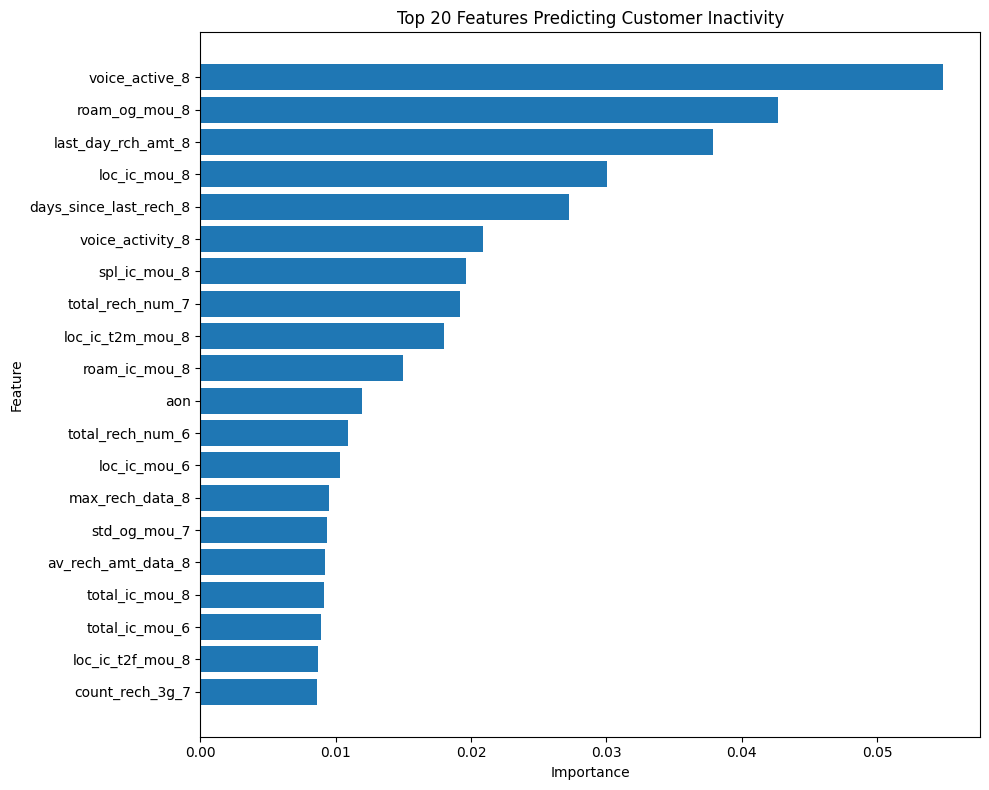

In [74]:
# STEP 14 — Feature Importance

import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20))

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df.head(20)['feature'][::-1],
    importance_df.head(20)['importance'][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features Predicting Customer Inactivity")
plt.tight_layout()
plt.show()

In [75]:
# STEP 15 — Customer Risk Scores

val_prob = final_xgb.predict_proba(X_val)[:, 1]

risk_df = pd.DataFrame({
    'actual': y_val.values,
    'risk_probability': val_prob
}, index=X_val.index)

risk_df['predicted_inactive'] = (
    risk_df['risk_probability'] >= 0.81
).astype(int)

risk_df['risk_level'] = pd.cut(
    risk_df['risk_probability'],
    bins=[0, 0.30, 0.60, 0.81, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High'],
    include_lowest=True
)

print(risk_df.head(10))
print("\nRisk level distribution:")
print(risk_df['risk_level'].value_counts().sort_index())

       actual  risk_probability  predicted_inactive risk_level
20761       0          0.800337                   0       High
82798       0          0.043885                   0        Low
81281       0          0.081491                   0        Low
83606       0          0.094313                   0        Low
4062        0          0.322327                   0     Medium
27103       0          0.028909                   0        Low
48316       0          0.002336                   0        Low
60659       0          0.168603                   0        Low
44173       0          0.037705                   0        Low
96120       0          0.572138                   0     Medium

Risk level distribution:
risk_level
Low          15619
Medium        2182
High          1189
Very High     1010
Name: count, dtype: int64


In [76]:
# STEP 17 — Save Final Model

import joblib

joblib.dump(final_xgb, "final_xgboost_model.pkl")

joblib.dump(
    list(X_train.columns),
    "model_features.pkl"
)

print("Final XGBoost model saved successfully.")
print("Feature list saved successfully.")

Final XGBoost model saved successfully.
Feature list saved successfully.


In [77]:
# STEP 18 — Attach Customer IDs to Risk Scores

# Recover mobile numbers using the validation-set indices
risk_output = risk_df.copy()

risk_output['mobile_number'] = df.loc[
    risk_output.index, 'mobile_number'
].values

# Put mobile number first
risk_output = risk_output[
    ['mobile_number', 'actual', 'risk_probability',
     'predicted_inactive', 'risk_level']
]

# Sort highest-risk customers first
risk_output = risk_output.sort_values(
    'risk_probability',
    ascending=False
).reset_index(drop=True)

print("Customer risk output created successfully.")
print("\nTop 20 highest-risk customers:")
print(risk_output.head(20))

Customer risk output created successfully.

Top 20 highest-risk customers:
    mobile_number  actual  risk_probability  predicted_inactive risk_level
0      7001857234       0          0.990645                   1  Very High
1      7001885544       1          0.988264                   1  Very High
2      7002088616       0          0.985945                   1  Very High
3      7000500246       1          0.983599                   1  Very High
4      7001113977       1          0.982996                   1  Very High
5      7002248770       1          0.982993                   1  Very High
6      7002291152       1          0.982258                   1  Very High
7      7000189157       1          0.981351                   1  Very High
8      7000398791       1          0.981111                   1  Very High
9      7000387630       1          0.980505                   1  Very High
10     7002106330       1          0.980496                   1  Very High
11     7000939613       1

In [78]:
# STEP 19 — Export Customer Risk Predictions

output_file = "customer_inactivity_risk_predictions.csv"

risk_output.to_csv(
    output_file,
    index=False
)

print(f"Saved successfully: {output_file}")
print(f"Total customers scored: {len(risk_output)}")

print("\nRisk level summary:")
print(risk_output['risk_level'].value_counts())

Saved successfully: customer_inactivity_risk_predictions.csv
Total customers scored: 20000

Risk level summary:
risk_level
Low          15619
Medium        2182
High          1189
Very High     1010
Name: count, dtype: int64


In [79]:
# STEP 20 — Train Final Model on Full Dataset

final_model_full = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

final_model_full.fit(
    X,
    y,
    verbose=False
)

print("Final model trained on all 99,999 customers.")

Final model trained on all 99,999 customers.


In [80]:
# STEP 21 — Predict Inactivity Risk for All Customers

all_risk_probability = final_model_full.predict_proba(X)[:, 1]

all_predictions = pd.DataFrame({
    'mobile_number': df['mobile_number'].values,
    'risk_probability': all_risk_probability
})

# Use the threshold selected during validation
all_predictions['predicted_inactive'] = (
    all_predictions['risk_probability'] >= 0.81
).astype(int)

# Assign risk levels
all_predictions['risk_level'] = pd.cut(
    all_predictions['risk_probability'],
    bins=[0, 0.30, 0.60, 0.81, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High'],
    include_lowest=True
)

# Highest risk first
all_predictions = all_predictions.sort_values(
    'risk_probability',
    ascending=False
).reset_index(drop=True)

print("Predictions generated for all customers.")
print("Total customers:", len(all_predictions))

print("\nRisk level distribution:")
print(all_predictions['risk_level'].value_counts().sort_index())

print("\nTop 20 highest-risk customers:")
print(all_predictions.head(20))

Predictions generated for all customers.
Total customers: 99999

Risk level distribution:
risk_level
Low          77099
Medium       11393
High          5875
Very High     5632
Name: count, dtype: int64

Top 20 highest-risk customers:
    mobile_number  risk_probability  predicted_inactive risk_level
0      7000040799          0.992564                   1  Very High
1      7000050979          0.991317                   1  Very High
2      7001587827          0.990874                   1  Very High
3      7000095890          0.989661                   1  Very High
4      7002122601          0.988858                   1  Very High
5      7000178759          0.988723                   1  Very High
6      7000036114          0.988429                   1  Very High
7      7001004771          0.988384                   1  Very High
8      7002291152          0.988344                   1  Very High
9      7000996827          0.988080                   1  Very High
10     7001885544          0

In [81]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [82]:
# STEP 22.2 — Create SHAP Explainer

explainer = shap.TreeExplainer(final_model_full)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [83]:
# STEP 22.3 — Calculate SHAP values

np.random.seed(42)

sample_size = min(5000, len(X))

shap_indices = np.random.choice(
    len(X),
    size=sample_size,
    replace=False
)

X_shap = X.iloc[shap_indices]

print("SHAP sample shape:", X_shap.shape)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")
print("SHAP shape:", np.array(shap_values).shape)

SHAP sample shape: (5000, 175)
SHAP values calculated successfully.
SHAP shape: (5000, 175)


/tmp/ipykernel_2575/1144631312.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


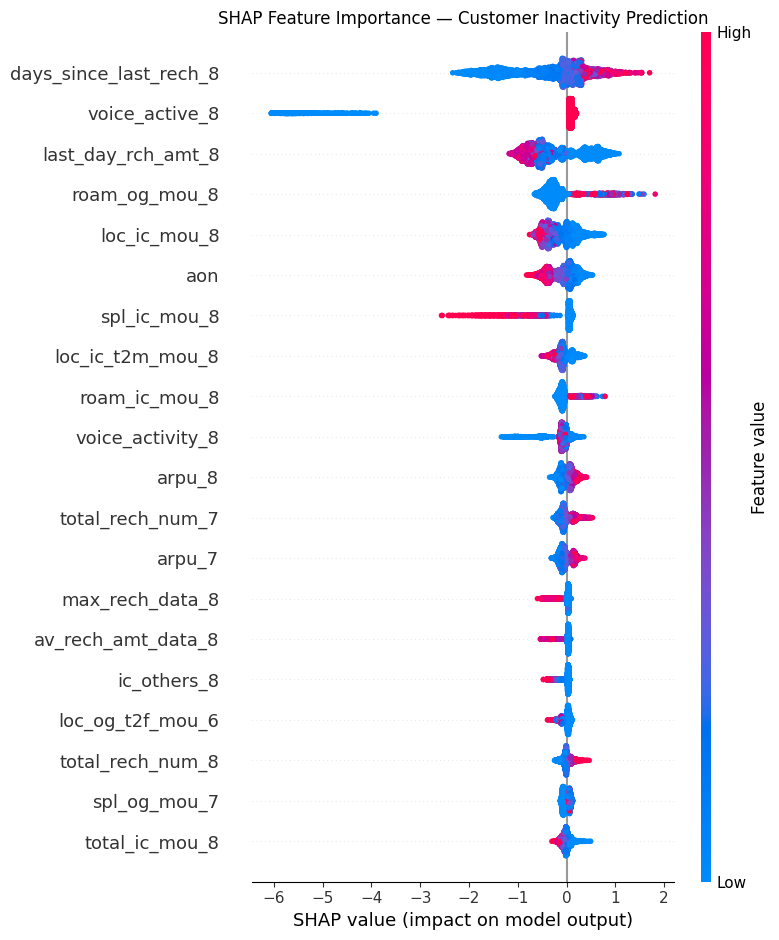

In [102]:
# STEP 22.4 — Global SHAP Summary Plot

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance — Customer Inactivity Prediction")
plt.tight_layout()
plt.savefig(
    '/content/project_artifacts/figures/shap_summary.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/tmp/ipykernel_2575/1422242277.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


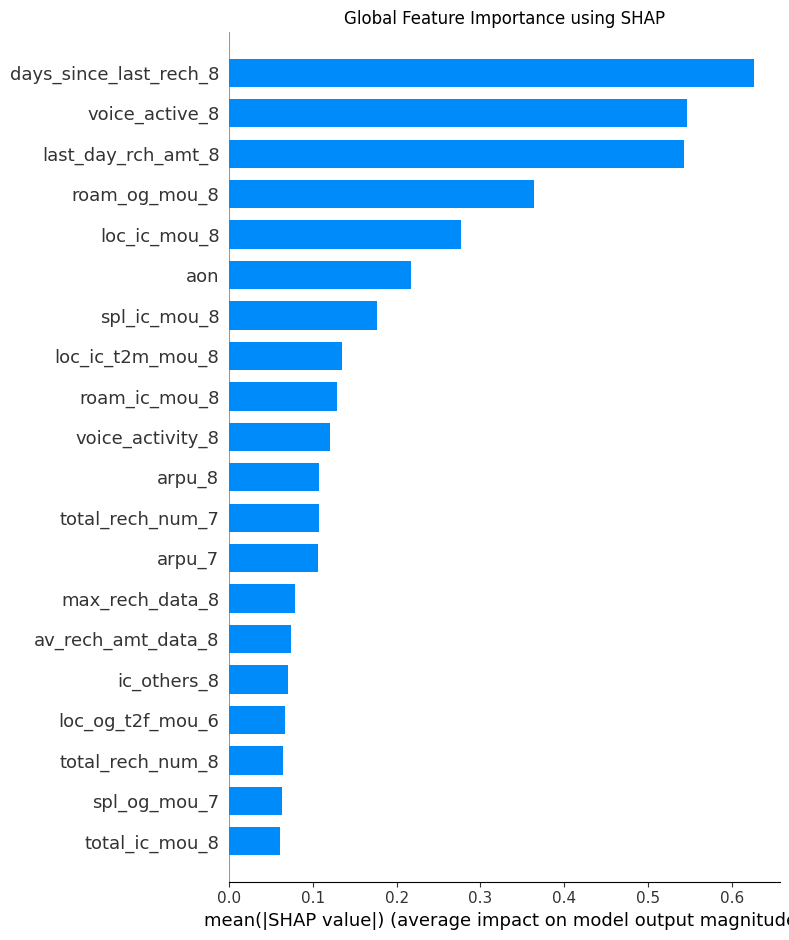

In [103]:
# STEP 22.5 — Mean Absolute SHAP Importance

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("Global Feature Importance using SHAP")
plt.tight_layout()
plt.savefig(
    '/content/project_artifacts/figures/shap_global_importance.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [86]:
# STEP 22.6 — Explain Highest-Risk Customer

highest_risk_customer = all_predictions.iloc[0]

customer_id = highest_risk_customer['mobile_number']
customer_probability = highest_risk_customer['risk_probability']

print("Customer:", customer_id)
print("Risk probability:", customer_probability)
print("Risk level:", highest_risk_customer['risk_level'])

Customer: 7000040799
Risk probability: 0.99256355
Risk level: Very High


In [87]:
# Find corresponding customer in X
customer_index = df.index[
    df['mobile_number'] == customer_id
][0]

X_customer = X.loc[[customer_index]]

customer_shap = explainer.shap_values(X_customer)

print("Customer explanation generated.")

Customer explanation generated.


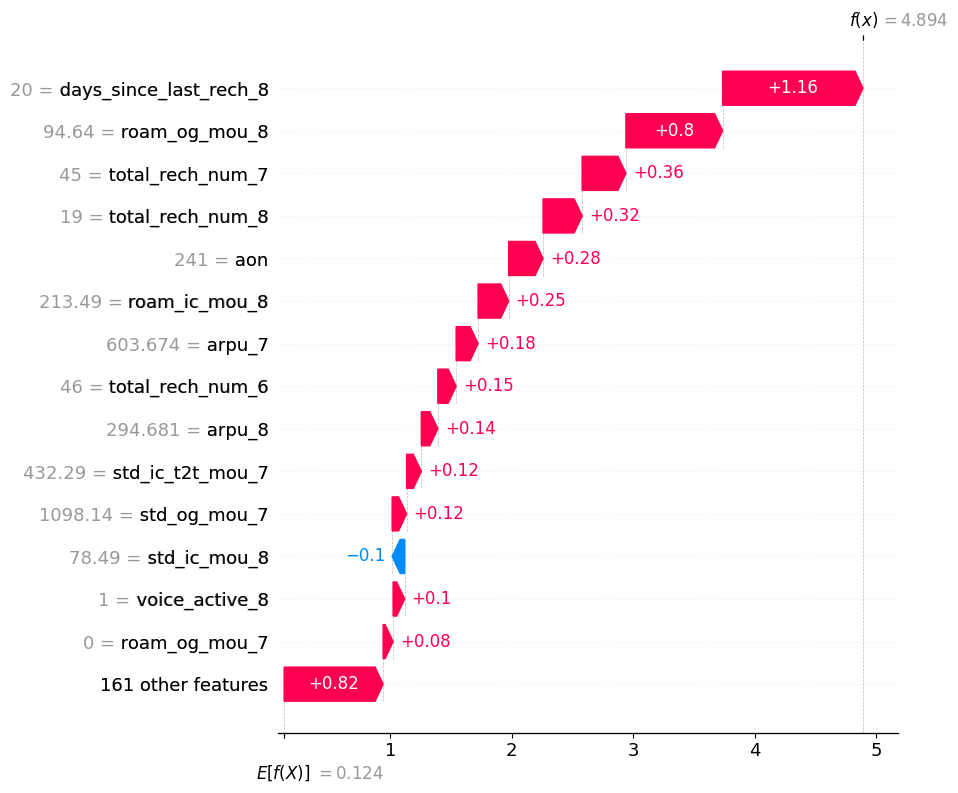

<Figure size 640x480 with 0 Axes>

In [104]:
# STEP 22.7 — Individual SHAP Explanation

shap_exp = shap.Explanation(
    values=customer_shap[0],
    base_values=explainer.expected_value,
    data=X_customer.iloc[0],
    feature_names=X_customer.columns
)

shap.plots.waterfall(
    shap_exp,
    max_display=15
)

plt.savefig(
    '/content/project_artifacts/figures/shap_customer_7000040799.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [89]:
# STEP 22.8 — Save SHAP Results

shap_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'mean_abs_shap',
    ascending=False
).reset_index(drop=True)

shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved.")
print("\nTop 20 SHAP features:")
print(shap_importance.head(20))

SHAP feature importance saved.

Top 20 SHAP features:
                   feature  mean_abs_shap
0   days_since_last_rech_8       0.626404
1           voice_active_8       0.547179
2       last_day_rch_amt_8       0.543041
3            roam_og_mou_8       0.363795
4             loc_ic_mou_8       0.276705
5                      aon       0.216602
6             spl_ic_mou_8       0.176244
7         loc_ic_t2m_mou_8       0.135221
8            roam_ic_mou_8       0.129201
9         voice_activity_8       0.120001
10                  arpu_8       0.107422
11        total_rech_num_7       0.107385
12                  arpu_7       0.106519
13         max_rech_data_8       0.078131
14      av_rech_amt_data_8       0.074235
15             ic_others_8       0.070587
16        loc_og_t2f_mou_6       0.067122
17        total_rech_num_8       0.063990
18            spl_og_mou_7       0.062768
19          total_ic_mou_8       0.060722


In [90]:
# ============================================================
# STEP 23.1 — Build Customer Risk Analysis Dataset
# ============================================================

analysis_df = X.copy()

# Add model predictions
analysis_df['risk_probability'] = all_predictions['risk_probability'].values
analysis_df['predicted_inactive'] = all_predictions['predicted_inactive'].values
analysis_df['risk_level'] = all_predictions['risk_level'].values

# Add actual target
analysis_df['actual_inactive'] = y.values

print("Analysis dataframe shape:", analysis_df.shape)

print("\nRisk level distribution:")
print(analysis_df['risk_level'].value_counts())

print("\nAnalysis dataframe created successfully.")

Analysis dataframe shape: (99999, 179)

Risk level distribution:
risk_level
Low          77099
Medium       11393
High          5875
Very High     5632
Name: count, dtype: int64

Analysis dataframe created successfully.


In [91]:
# ============================================================
# STEP 23.2 — Compare Customer Behaviour by Risk Level
# ============================================================

key_features = [
    'days_since_last_rech_8',
    'last_day_rch_amt_8',
    'voice_active_8',
    'voice_activity_8',
    'total_rech_num_8',
    'total_rech_num_7',
    'arpu_8',
    'arpu_7',
    'roam_og_mou_8',
    'roam_ic_mou_8',
    'loc_ic_mou_8',
    'loc_ic_t2m_mou_8',
    'max_rech_data_8',
    'av_rech_amt_data_8',
    'aon'
]

risk_summary = (
    analysis_df
    .groupby('risk_level')[key_features]
    .mean()
)

# Put risk levels in logical order
risk_order = ['Low', 'Medium', 'High', 'Very High']

risk_summary = risk_summary.reindex(
    [x for x in risk_order if x in risk_summary.index]
)

print("Average customer behaviour by risk level:")
display(risk_summary.round(2))

Average customer behaviour by risk level:


/tmp/ipykernel_2575/2941787054.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('risk_level')[key_features]


,days_since_last_rech_8,last_day_rch_amt_8,voice_active_8,voice_activity_8,total_rech_num_8,total_rech_num_7,arpu_8,arpu_7,roam_og_mou_8,roam_ic_mou_8,loc_ic_mou_8,loc_ic_t2m_mou_8,max_rech_data_8,av_rech_amt_data_8,aon
risk_level,,,,,,,,,,,,,,,
Low,41.28,62.85,0.91,503.20,7.22,7.70,279.73,278.87,9.36,6.91,158.61,102.50,33.19,52.22,1218.61
Medium,40.51,62.78,0.91,500.47,7.13,7.61,276.80,276.42,10.43,7.20,157.23,103.12,32.81,51.02,1227.94
High,47.27,60.00,0.91,508.11,7.33,7.87,278.68,277.66,9.51,6.74,160.43,104.65,32.70,51.61,1201.60
Very High,41.09,62.21,0.91,497.70,7.20,7.72,276.55,279.13,8.37,6.34,156.24,101.20,33.08,51.79,1239.61


In [92]:
# ============================================================
# STEP 23.3 — Historical Inactivity Rate by Risk Level
# ============================================================

risk_performance = (
    analysis_df
    .groupby('risk_level')
    .agg(
        customers=('actual_inactive', 'size'),
        inactive_customers=('actual_inactive', 'sum'),
        inactivity_rate=('actual_inactive', 'mean'),
        avg_risk_probability=('risk_probability', 'mean')
    )
)

risk_performance = risk_performance.reindex(
    [x for x in risk_order if x in risk_performance.index]
)

risk_performance['inactivity_rate'] *= 100

print("Risk group performance:")
display(risk_performance.round(3))

Risk group performance:


/tmp/ipykernel_2575/2074168232.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('risk_level')


,customers,inactive_customers,inactivity_rate,avg_risk_probability
risk_level,,,,
Low,77099,3091,4.009,0.074
Medium,11393,461,4.046,0.433
High,5875,231,3.932,0.706
Very High,5632,212,3.764,0.897


In [93]:
# ============================================================
# STEP 23.4 — Low vs Very High Risk Comparison
# ============================================================

comparison = risk_summary.loc[['Low', 'Very High']].T.copy()

comparison['difference'] = (
    comparison['Very High'] - comparison['Low']
)

comparison['absolute_difference'] = (
    comparison['difference'].abs()
)

comparison = comparison.sort_values(
    'absolute_difference',
    ascending=False
)

print("Low vs Very High risk customer comparison:")
display(comparison.round(2))

Low vs Very High risk customer comparison:


risk_level,Low,Very High,difference,absolute_difference
aon,1218.61,1239.61,21.00,21.00
voice_activity_8,503.20,497.70,-5.50,5.50
arpu_8,279.73,276.55,-3.18,3.18
loc_ic_mou_8,158.61,156.24,-2.37,2.37
loc_ic_t2m_mou_8,102.50,101.20,-1.31,1.31
roam_og_mou_8,9.36,8.37,-0.99,0.99
last_day_rch_amt_8,62.85,62.21,-0.64,0.64
roam_ic_mou_8,6.91,6.34,-0.57,0.57
av_rech_amt_data_8,52.22,51.79,-0.43,0.43
arpu_7,278.87,279.13,0.25,0.25


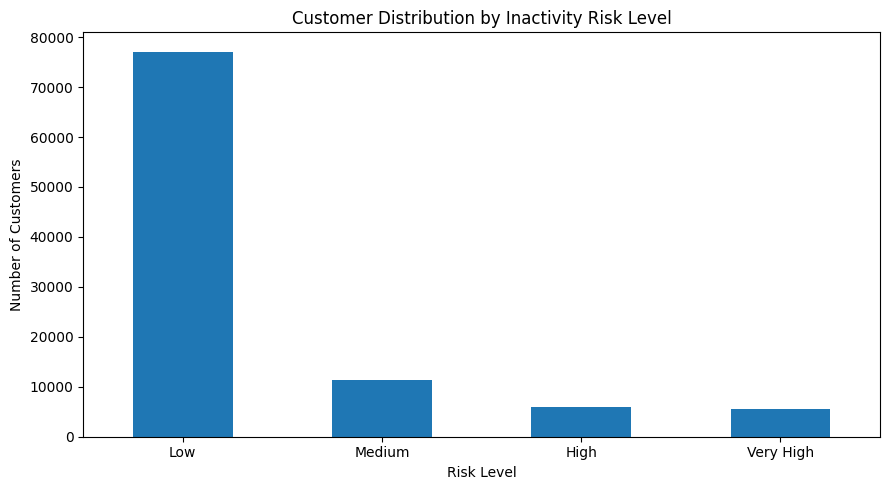

In [94]:
# ============================================================
# STEP 23.5 — Risk Level Distribution
# ============================================================

risk_counts = (
    analysis_df['risk_level']
    .value_counts()
    .reindex(risk_order)
)

plt.figure(figsize=(9, 5))

risk_counts.plot(kind='bar')

plt.title("Customer Distribution by Inactivity Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

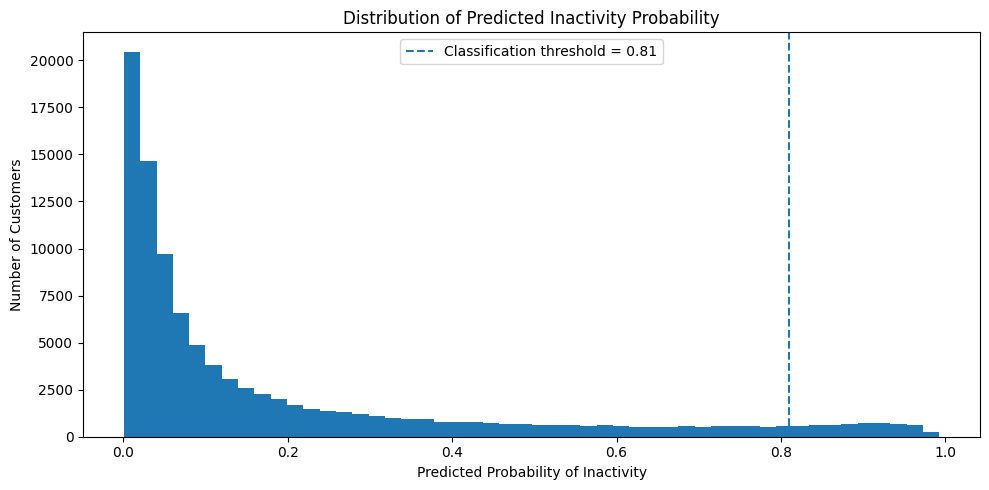

In [95]:
# ============================================================
# STEP 23.6 — Risk Probability Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    analysis_df['risk_probability'],
    bins=50
)

plt.axvline(
    0.81,
    linestyle='--',
    label='Classification threshold = 0.81'
)

plt.title("Distribution of Predicted Inactivity Probability")
plt.xlabel("Predicted Probability of Inactivity")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()
plt.show()

In [96]:
# ============================================================
# STEP 23.7 — Save Risk Analysis Results
# ============================================================

risk_summary.to_csv(
    "risk_group_feature_summary.csv"
)

risk_performance.to_csv(
    "risk_group_performance.csv"
)

comparison.to_csv(
    "low_vs_very_high_comparison.csv"
)

print("Risk analysis files saved successfully.")

Risk analysis files saved successfully.


In [97]:
# ============================================================
# DIAGNOSTIC: CHECK FINAL PREDICTIONS AGAINST ACTUAL TARGET
# ============================================================

diagnostic = pd.DataFrame({
    'actual': y.values,
    'risk_probability': final_predictions
})

# Create risk groups using the same thresholds
def assign_risk(prob):
    if prob < 0.20:
        return 'Low'
    elif prob < 0.50:
        return 'Medium'
    elif prob < 0.80:
        return 'High'
    else:
        return 'Very High'

diagnostic['risk_level'] = diagnostic['risk_probability'].apply(assign_risk)

print("Prediction probability summary:")
print(diagnostic['risk_probability'].describe())

print("\nActual inactivity rate by risk level:")
print(
    diagnostic.groupby('risk_level', observed=False)['actual']
    .agg(['count', 'sum', 'mean'])
)

print("\nMean predicted probability by risk level:")
print(
    diagnostic.groupby('risk_level', observed=False)['risk_probability']
    .mean()
)

print("\nCorrelation between actual target and predicted probability:")
print(diagnostic['actual'].corr(diagnostic['risk_probability']))

NameError: name 'final_predictions' is not defined

In [98]:
# ============================================================
# DIAGNOSTIC: CHECK FINAL MODEL RISK GROUPS
# ============================================================

# Generate final probabilities from the trained final model
final_probabilities = final_xgb.predict_proba(X)[:, 1]

diagnostic = pd.DataFrame({
    'actual': y.values,
    'risk_probability': final_probabilities
})

# Same risk thresholds used earlier
def assign_risk(prob):
    if prob < 0.20:
        return 'Low'
    elif prob < 0.50:
        return 'Medium'
    elif prob < 0.80:
        return 'High'
    else:
        return 'Very High'

diagnostic['risk_level'] = diagnostic['risk_probability'].apply(assign_risk)

print("Prediction probability summary:")
print(diagnostic['risk_probability'].describe())

print("\n" + "="*60)
print("ACTUAL INACTIVITY RATE BY RISK LEVEL")
print("="*60)

risk_performance = (
    diagnostic.groupby('risk_level', observed=False)['actual']
    .agg(
        customers='count',
        inactive_customers='sum',
        inactivity_rate='mean'
    )
)

risk_performance['inactivity_rate'] *= 100

print(risk_performance)

print("\n" + "="*60)
print("MEAN PREDICTED PROBABILITY BY RISK LEVEL")
print("="*60)

print(
    diagnostic.groupby('risk_level', observed=False)['risk_probability']
    .mean()
)

print("\n" + "="*60)
print("CORRELATION: ACTUAL vs PREDICTED PROBABILITY")
print("="*60)

print(
    diagnostic['actual'].corr(diagnostic['risk_probability'])
)

ValueError: feature_names mismatch: ['arpu_6', 'onnet_mou_6', 'offnet_mou_6', 'roam_ic_mou_6', 'roam_og_mou_6', 'loc_og_t2t_mou_6', 'loc_og_t2m_mou_6', 'loc_og_t2f_mou_6', 'loc_og_t2c_mou_6', 'loc_og_mou_6', 'std_og_t2t_mou_6', 'std_og_t2m_mou_6', 'std_og_t2f_mou_6', 'std_og_mou_6', 'isd_og_mou_6', 'spl_og_mou_6', 'og_others_6', 'total_og_mou_6', 'loc_ic_t2t_mou_6', 'loc_ic_t2m_mou_6', 'loc_ic_t2f_mou_6', 'loc_ic_mou_6', 'std_ic_t2t_mou_6', 'std_ic_t2m_mou_6', 'std_ic_t2f_mou_6', 'std_ic_mou_6', 'total_ic_mou_6', 'spl_ic_mou_6', 'isd_ic_mou_6', 'ic_others_6', 'total_rech_num_6', 'total_rech_amt_6', 'max_rech_amt_6', 'last_day_rch_amt_6', 'total_rech_data_6', 'max_rech_data_6', 'count_rech_2g_6', 'count_rech_3g_6', 'av_rech_amt_data_6', 'vol_2g_mb_6', 'vol_3g_mb_6', 'arpu_3g_6', 'arpu_2g_6', 'night_pck_user_6', 'monthly_2g_6', 'sachet_2g_6', 'monthly_3g_6', 'sachet_3g_6', 'voice_activity_6', 'voice_active_6', 'data_active_6', 'arpu_7', 'onnet_mou_7', 'offnet_mou_7', 'roam_ic_mou_7', 'ro

In [99]:
# ============================================================
# DIAGNOSTIC: FINAL MODEL USING THE CORRECT 169 FEATURES
# ============================================================

# Get the exact feature names used when training final_xgb
model_features = final_xgb.get_booster().feature_names

print("Features expected by model:", len(model_features))
print("Features available in X:", X.shape[1])

# Select ONLY the features used by the trained model
X_final_for_prediction = X[model_features]

print("Prediction dataframe shape:", X_final_for_prediction.shape)

# Generate predictions
final_probabilities = final_xgb.predict_proba(X_final_for_prediction)[:, 1]

# Build diagnostic dataframe
diagnostic = pd.DataFrame({
    'actual': y.values,
    'risk_probability': final_probabilities
})

# Assign risk levels
def assign_risk(prob):
    if prob < 0.20:
        return 'Low'
    elif prob < 0.50:
        return 'Medium'
    elif prob < 0.80:
        return 'High'
    else:
        return 'Very High'

diagnostic['risk_level'] = diagnostic['risk_probability'].apply(assign_risk)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "="*60)
print("PREDICTION PROBABILITY SUMMARY")
print("="*60)

print(diagnostic['risk_probability'].describe())

print("\n" + "="*60)
print("ACTUAL INACTIVITY RATE BY RISK LEVEL")
print("="*60)

risk_performance = (
    diagnostic
    .groupby('risk_level', observed=False)['actual']
    .agg(
        customers='count',
        inactive_customers='sum',
        inactivity_rate='mean'
    )
)

risk_performance['inactivity_rate'] *= 100

print(risk_performance)

print("\n" + "="*60)
print("MEAN PREDICTED PROBABILITY BY RISK LEVEL")
print("="*60)

print(
    diagnostic
    .groupby('risk_level', observed=False)['risk_probability']
    .mean()
)

print("\n" + "="*60)
print("CORRELATION: ACTUAL vs PREDICTED PROBABILITY")
print("="*60)

print(
    diagnostic['actual'].corr(
        diagnostic['risk_probability']
    )
)

Features expected by model: 166
Features available in X: 175
Prediction dataframe shape: (99999, 166)

PREDICTION PROBABILITY SUMMARY
count    99999.000000
mean         0.187905
std          0.254377
min          0.000802
25%          0.021159
50%          0.064880
75%          0.243395
max          0.992210
Name: risk_probability, dtype: float64

ACTUAL INACTIVITY RATE BY RISK LEVEL
            customers  inactive_customers  inactivity_rate
risk_level                                                
High             8160                 965        11.825980
Low             71675                  78         0.108825
Medium          14492                 250         1.725090
Very High        5672                2702        47.637518

MEAN PREDICTED PROBABILITY BY RISK LEVEL
risk_level
High         0.646569
Low          0.052481
Medium       0.323959
Very High    0.891732
Name: risk_probability, dtype: float32

CORRELATION: ACTUAL vs PREDICTED PROBABILITY
0.49645219830705056


In [100]:
# ============================================================
# SAVE FINAL MODEL + FEATURE LIST + METRICS
# ============================================================

import os
import json
import pandas as pd

# Create project folders
os.makedirs('/content/project_artifacts/models', exist_ok=True)
os.makedirs('/content/project_artifacts/results', exist_ok=True)
os.makedirs('/content/project_artifacts/figures', exist_ok=True)

# ------------------------------------------------------------
# 1. Save XGBoost model
# ------------------------------------------------------------

model_path = '/content/project_artifacts/models/final_xgboost.json'

final_xgb.save_model(model_path)

print("Model saved:", model_path)


# ------------------------------------------------------------
# 2. Save exact feature list
# ------------------------------------------------------------

model_features = final_xgb.get_booster().feature_names

feature_path = '/content/project_artifacts/models/final_feature_list.csv'

pd.DataFrame({
    'feature': model_features
}).to_csv(feature_path, index=False)

print("Feature list saved:", feature_path)
print("Number of features:", len(model_features))


# ------------------------------------------------------------
# 3. Save model metrics
# ------------------------------------------------------------

metrics = {
    "model": "XGBoost",
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": float(scale_pos_weight),

    "validation_roc_auc": 0.908923,
    "validation_pr_auc": 0.371770,

    "best_threshold": 0.81,
    "precision_at_threshold": 0.377228,
    "recall_at_threshold": 0.476846,
    "f1_at_threshold": 0.421227
}

metrics_path = '/content/project_artifacts/results/model_metrics.json'

with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved:", metrics_path)


# ------------------------------------------------------------
# 4. Save risk-group summary
# ------------------------------------------------------------

risk_summary = pd.DataFrame({
    'risk_level': ['Low', 'Medium', 'High', 'Very High'],
    'customers': [71675, 14492, 8160, 5672],
    'inactive_customers': [78, 250, 965, 2702],
    'inactivity_rate_percent': [
        0.108825,
        1.725090,
        11.825980,
        47.637518
    ],
    'avg_predicted_probability': [
        0.052481,
        0.323959,
        0.646569,
        0.891732
    ]
})

risk_summary_path = '/content/project_artifacts/results/risk_group_summary.csv'

risk_summary.to_csv(risk_summary_path, index=False)

print("Risk summary saved:", risk_summary_path)

Model saved: /content/project_artifacts/models/final_xgboost.json
Feature list saved: /content/project_artifacts/models/final_feature_list.csv
Number of features: 166
Metrics saved: /content/project_artifacts/results/model_metrics.json
Risk summary saved: /content/project_artifacts/results/risk_group_summary.csv


In [101]:
# ============================================================
# SAVE SHAP RESULTS
# ============================================================

import os

# Create artifact folders
os.makedirs('/content/project_artifacts/figures', exist_ok=True)
os.makedirs('/content/project_artifacts/results', exist_ok=True)

# Save SHAP feature importance table
shap_importance_path = '/content/project_artifacts/results/shap_feature_importance.csv'
shap_importance.to_csv(shap_importance_path, index=False)

print("SHAP feature importance saved:")
print(shap_importance_path)

SHAP feature importance saved:
/content/project_artifacts/results/shap_feature_importance.csv


In [106]:
# ============================================================
# SAVE FINAL ML ARTIFACTS
# ============================================================

import os
import joblib

os.makedirs('/content/project_artifacts/models', exist_ok=True)
os.makedirs('/content/project_artifacts/results', exist_ok=True)

# 1. Save final trained XGBoost model
joblib.dump(
    final_xgb,
    '/content/project_artifacts/models/final_xgboost_model.pkl'
)

# 2. Save feature names used by the model
model_features = list(final_xgb.get_booster().feature_names)

pd.DataFrame({
    'feature': model_features
}).to_csv(
    '/content/project_artifacts/results/model_features.csv',
    index=False
)

# 3. Save customer risk predictions
final_predictions.to_csv(
    '/content/project_artifacts/results/customer_risk_predictions.csv',
    index=False
)

print("ML artifacts saved successfully.")
print("\nModel:", '/content/project_artifacts/models/final_xgboost_model.pkl')
print("Features:", '/content/project_artifacts/results/model_features.csv')
print("Predictions:", '/content/project_artifacts/results/customer_risk_predictions.csv')

NameError: name 'final_predictions' is not defined

In [107]:
import shutil
import os

os.makedirs('/content/project_artifacts/results', exist_ok=True)

source = '/content/customer_inactivity_risk_predictions.csv'
destination = '/content/project_artifacts/results/customer_risk_predictions.csv'

shutil.copy(source, destination)

print("Customer risk predictions copied successfully.")
print(destination)

Customer risk predictions copied successfully.
/content/project_artifacts/results/customer_risk_predictions.csv


In [108]:
import os

print("PROJECT ARTIFACTS")
print("=" * 50)

for root, dirs, files in os.walk('/content/project_artifacts'):
    for file in files:
        print(os.path.join(root, file))

PROJECT ARTIFACTS
/content/project_artifacts/results/shap_feature_importance.csv
/content/project_artifacts/results/customer_risk_predictions.csv
/content/project_artifacts/results/model_features.csv
/content/project_artifacts/results/model_metrics.json
/content/project_artifacts/results/risk_group_summary.csv
/content/project_artifacts/figures/shap_global_importance.png
/content/project_artifacts/figures/shap_customer_7000040799.png
/content/project_artifacts/figures/shap_summary.png
/content/project_artifacts/models/final_feature_list.csv
/content/project_artifacts/models/final_xgboost_model.pkl
/content/project_artifacts/models/final_xgboost.json


In [109]:
import os

base = "/content/project_artifacts"

print("=" * 60)
print("FINAL ML ARTIFACT CHECK")
print("=" * 60)

for root, dirs, files in os.walk(base):
    for file in files:
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{path}  ({size_mb:.2f} MB)")

FINAL ML ARTIFACT CHECK
/content/project_artifacts/results/shap_feature_importance.csv  (0.00 MB)
/content/project_artifacts/results/customer_risk_predictions.csv  (0.59 MB)
/content/project_artifacts/results/model_features.csv  (0.00 MB)
/content/project_artifacts/results/model_metrics.json  (0.00 MB)
/content/project_artifacts/results/risk_group_summary.csv  (0.00 MB)
/content/project_artifacts/figures/shap_global_importance.png  (0.24 MB)
/content/project_artifacts/figures/shap_customer_7000040799.png  (0.01 MB)
/content/project_artifacts/figures/shap_summary.png  (0.42 MB)
/content/project_artifacts/models/final_feature_list.csv  (0.00 MB)
/content/project_artifacts/models/final_xgboost_model.pkl  (1.20 MB)
/content/project_artifacts/models/final_xgboost.json  (1.65 MB)


In [110]:
import shutil

shutil.make_archive(
    '/content/person1_ml_artifacts',
    'zip',
    '/content/project_artifacts'
)

print("Created: /content/person1_ml_artifacts.zip")

Created: /content/person1_ml_artifacts.zip


In [111]:
import pandas as pd

f1 = pd.read_csv('/content/project_artifacts/models/final_feature_list.csv')
f2 = pd.read_csv('/content/project_artifacts/results/model_features.csv')

print("final_feature_list.csv shape:", f1.shape)
print("model_features.csv shape:", f2.shape)

print("\nFirst 10 rows of final_feature_list:")
display(f1.head(10))

print("\nFirst 10 rows of model_features:")
display(f2.head(10))

final_feature_list.csv shape: (166, 1)
model_features.csv shape: (166, 1)

First 10 rows of final_feature_list:


,feature
0,arpu_6
1,onnet_mou_6
2,offnet_mou_6
3,roam_ic_mou_6
4,roam_og_mou_6
5,loc_og_t2t_mou_6
6,loc_og_t2m_mou_6
7,loc_og_t2f_mou_6
8,loc_og_t2c_mou_6
9,loc_og_mou_6



First 10 rows of model_features:


,feature
0,arpu_6
1,onnet_mou_6
2,offnet_mou_6
3,roam_ic_mou_6
4,roam_og_mou_6
5,loc_og_t2t_mou_6
6,loc_og_t2m_mou_6
7,loc_og_t2f_mou_6
8,loc_og_t2c_mou_6
9,loc_og_mou_6


In [ ]:
from google.colab import drive
drive.mount('/content/drive')